 📊 GLOBAL FORECASTING PERFORMANCE (ALL DATA) 
RMSE (Root Mean Squared Error):  8,876.91
MAE (Mean Absolute Error):       4,425.30
Mean Bias (Overall Direction):   -3,416.27 (Under-predicting)
MAPE (Mean Abs Percentage):      9.27%
Match Accuracy (Within ±5%):     37.75% of predictions
Match Accuracy (Within ±10%):    68.87% of predictions



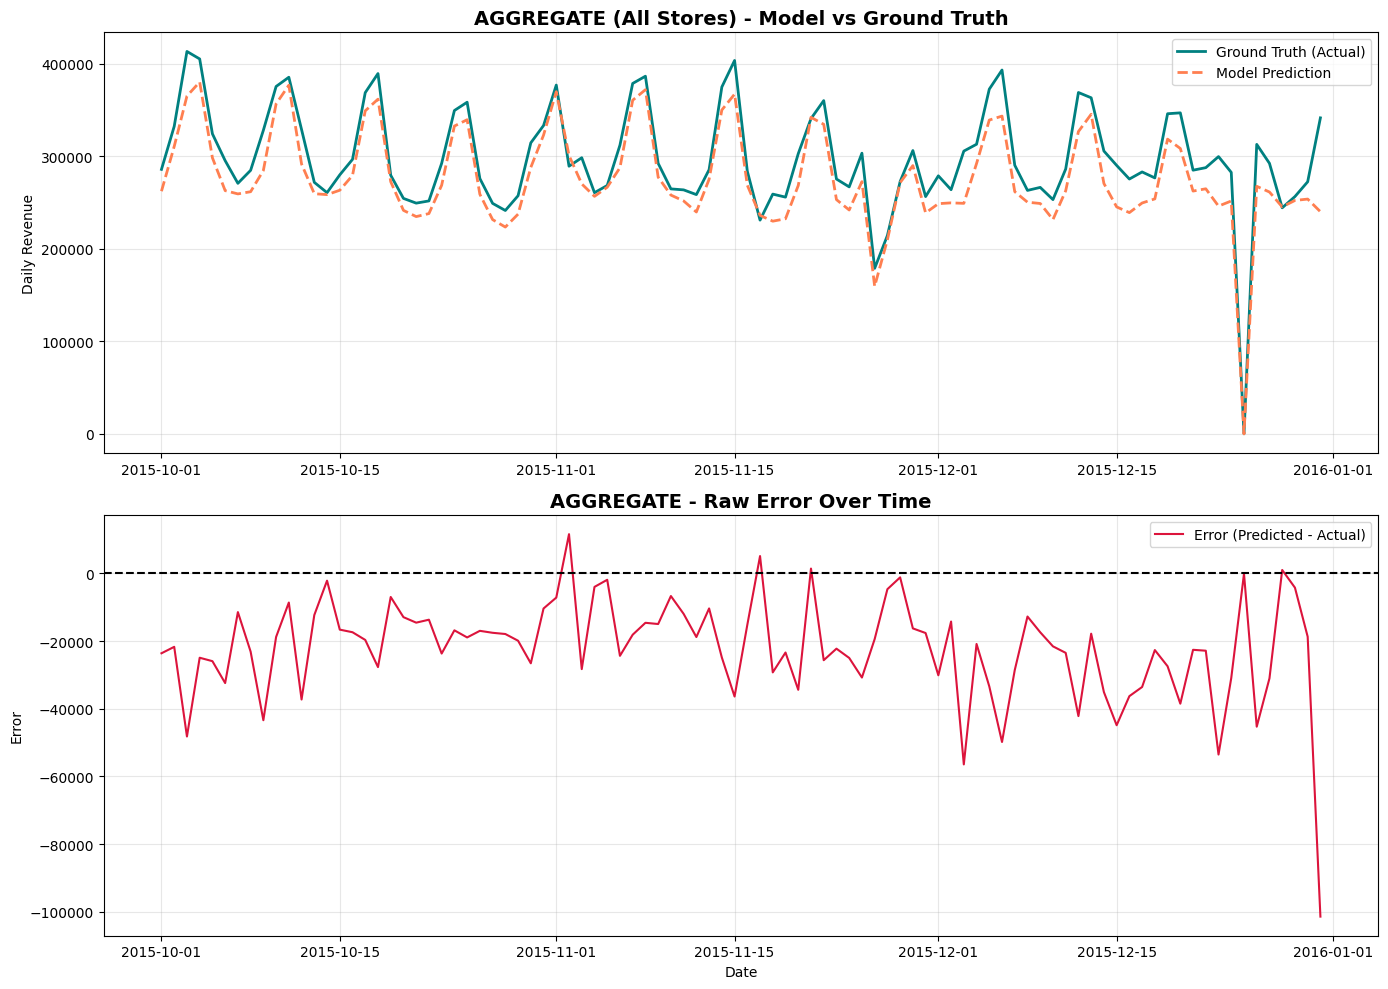


 🏪 INDIVIDUAL STORE BREAKDOWN 

▶ STORE 1 METRICS:
  RMSE: 2,361.28  |  MAE: 1,857.88  |  MAPE: 5.57%


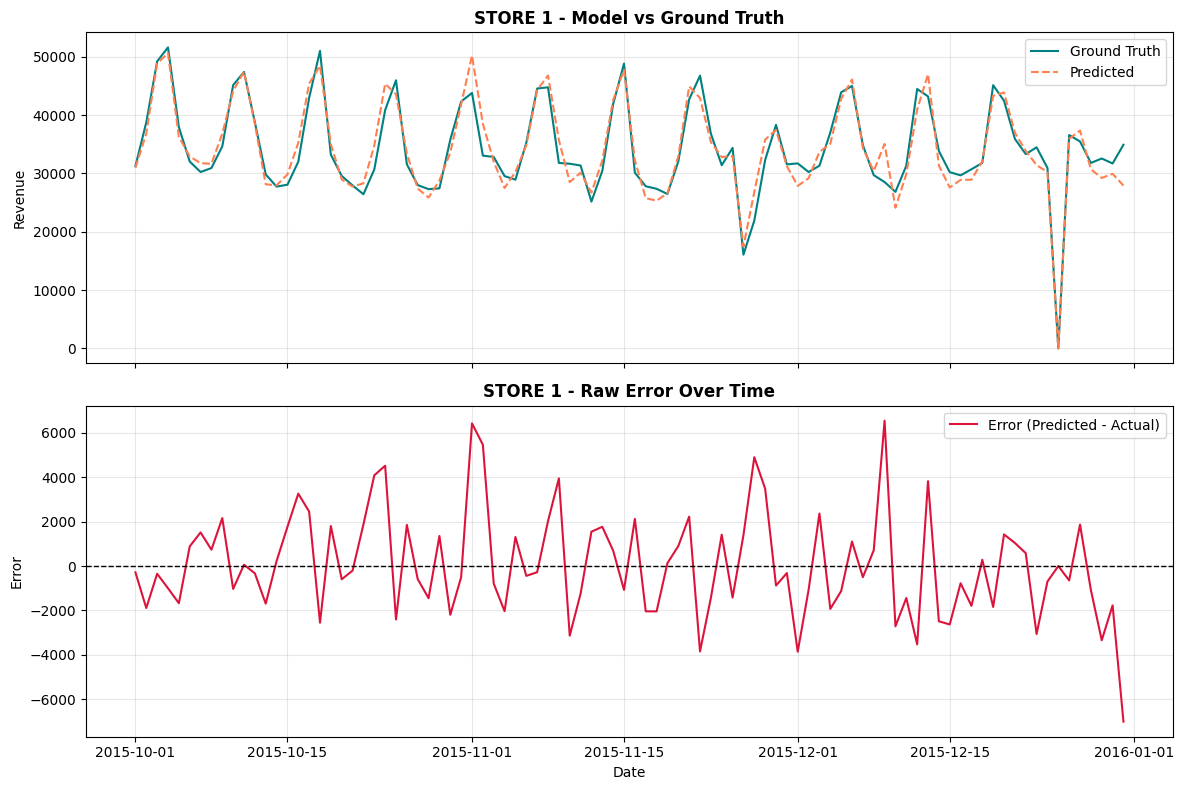


▶ STORE 2 METRICS:
  RMSE: 6,698.68  |  MAE: 5,822.14  |  MAPE: 18.14%


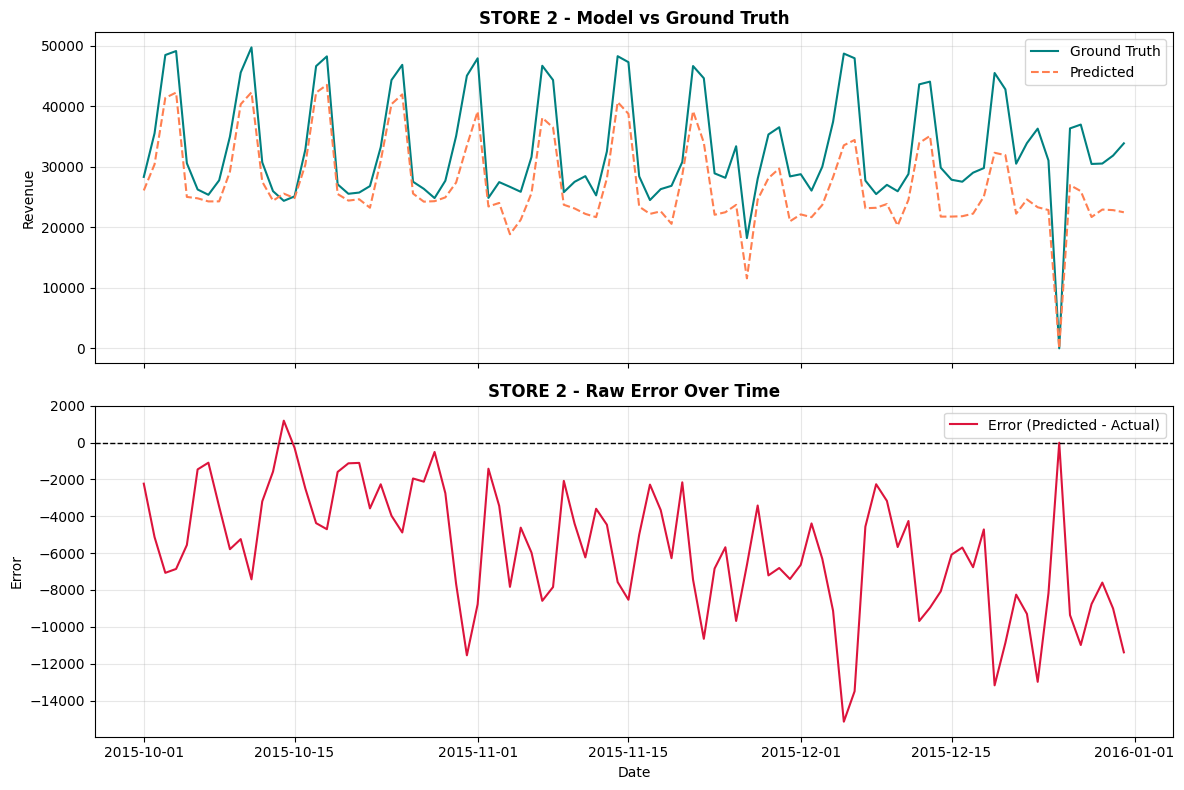


▶ STORE 3 METRICS:
  RMSE: 3,648.45  |  MAE: 2,570.52  |  MAPE: 6.79%


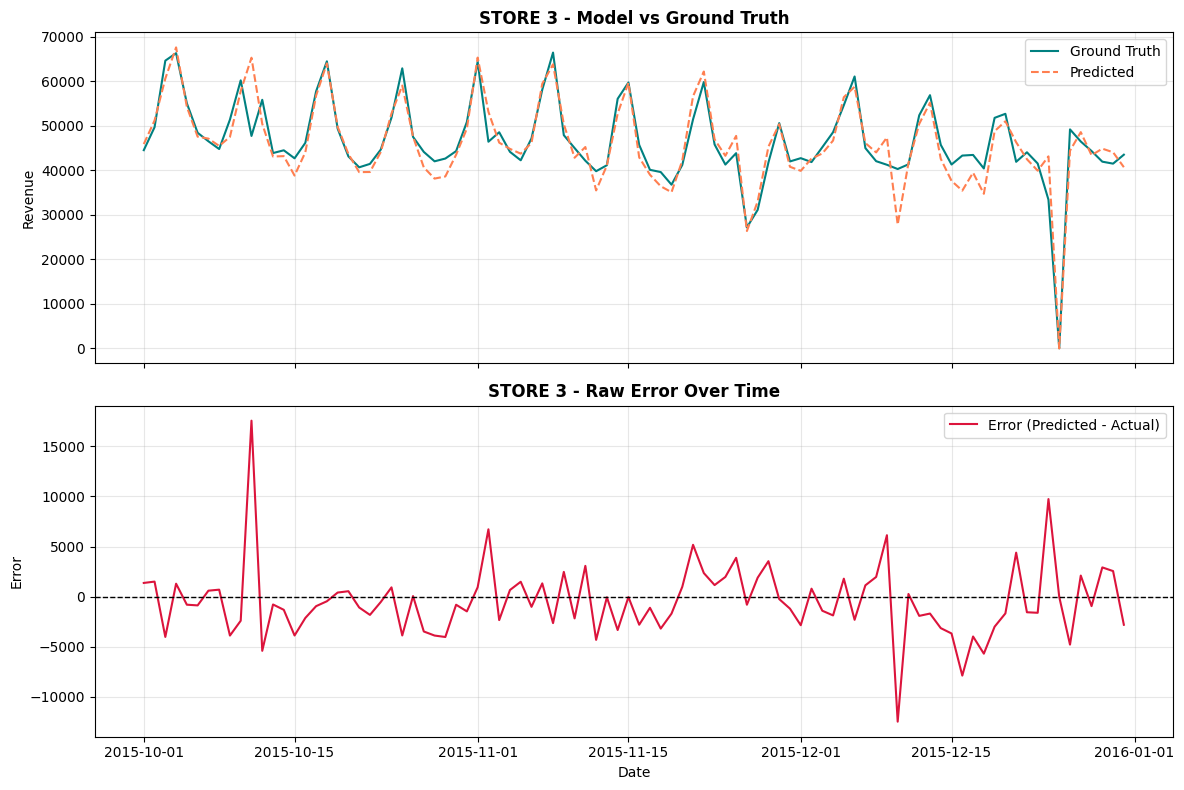


▶ STORE 4 METRICS:
  RMSE: 1,392.81  |  MAE: 1,133.73  |  MAPE: 5.92%


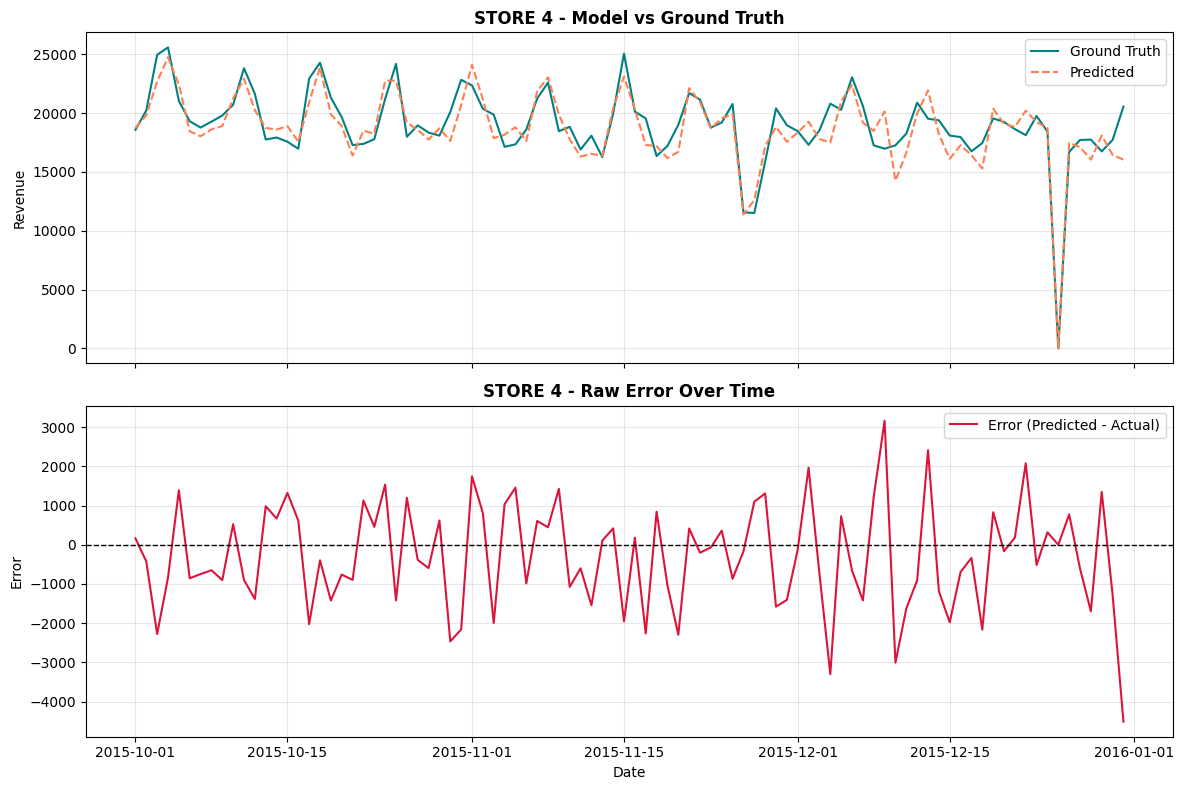


▶ STORE 5 METRICS:
  RMSE: 1,723.09  |  MAE: 1,324.64  |  MAPE: 6.74%


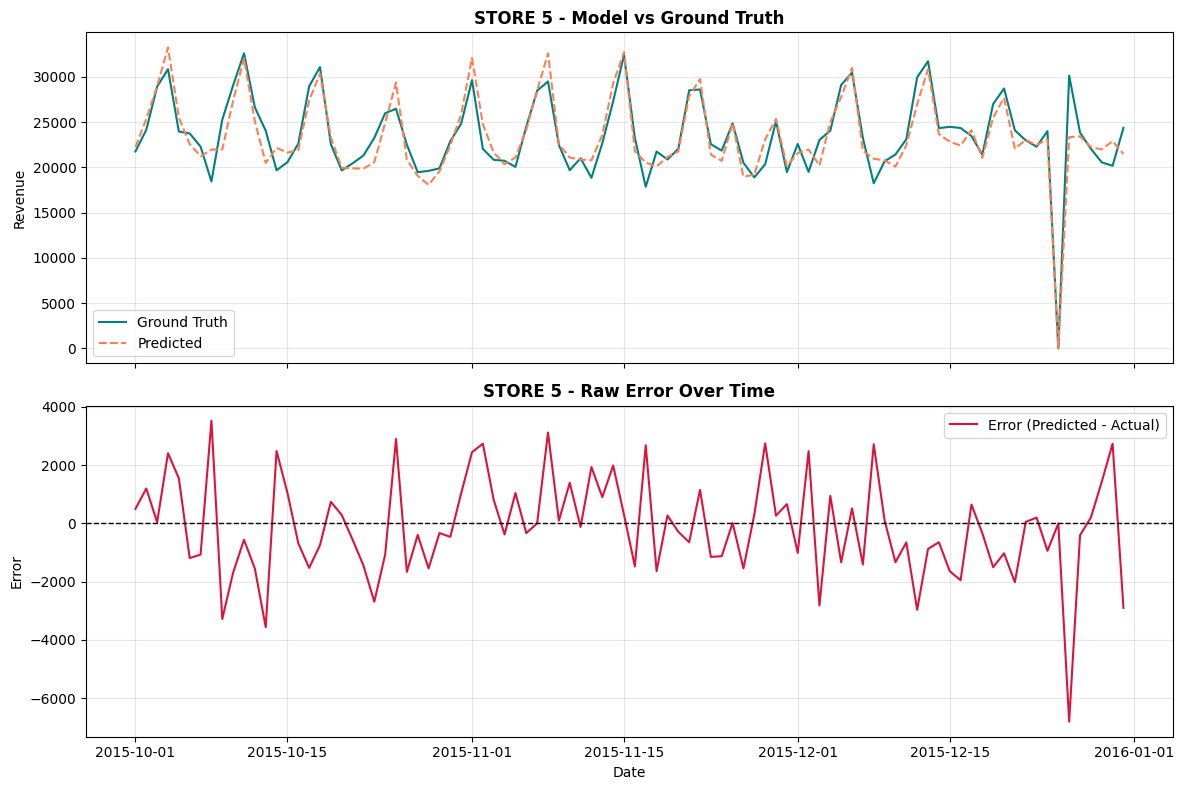


▶ STORE 6 METRICS:
  RMSE: 2,794.56  |  MAE: 2,199.93  |  MAPE: 7.43%


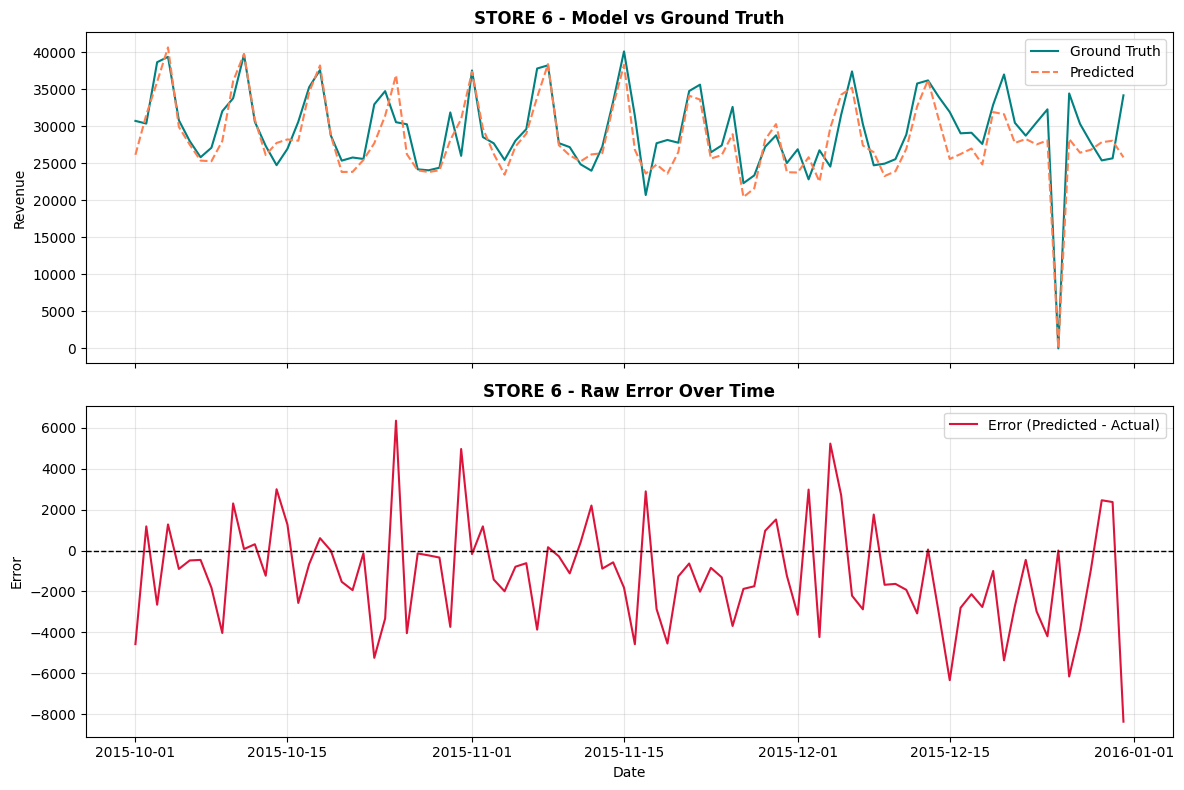


▶ STORE 7 METRICS:
  RMSE: 3,692.56  |  MAE: 3,030.07  |  MAPE: 10.87%


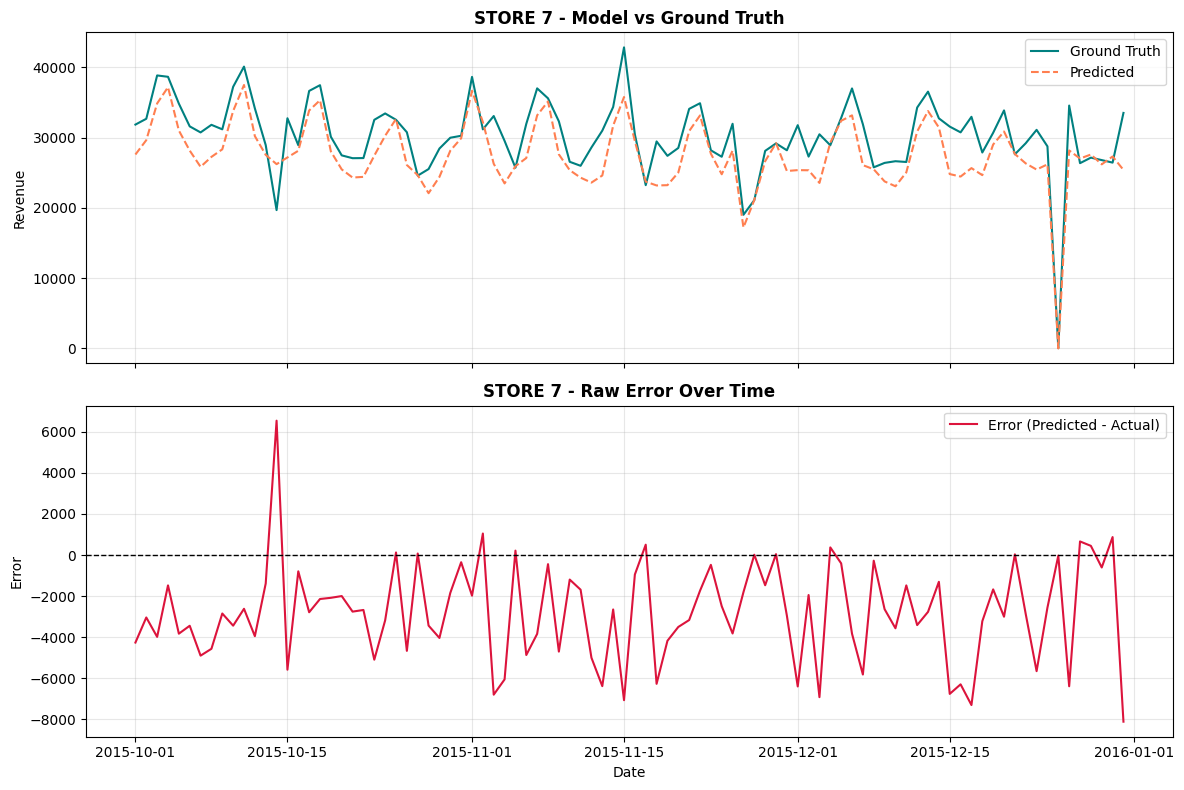


▶ STORE 8 METRICS:
  RMSE: 3,184.98  |  MAE: 2,125.88  |  MAPE: 9.20%


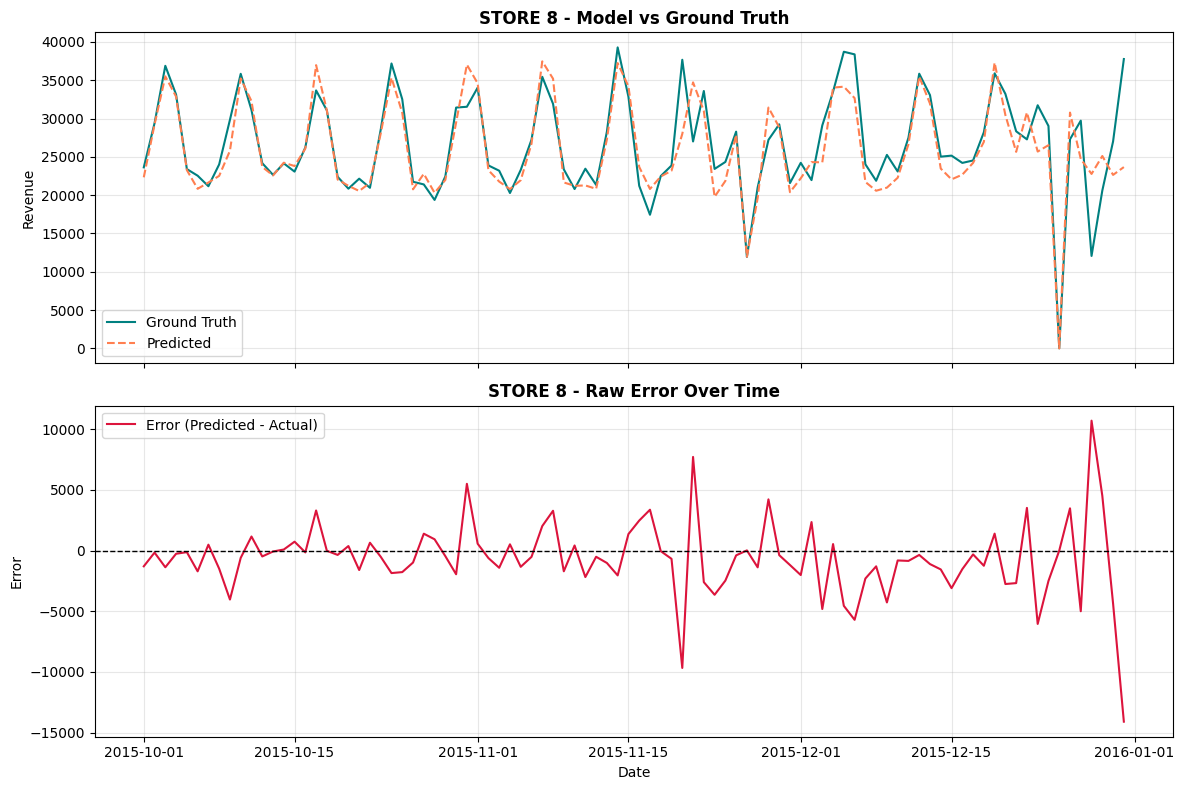


▶ STORE 9 METRICS:
  RMSE: 5,186.58  |  MAE: 3,596.42  |  MAPE: 11.92%


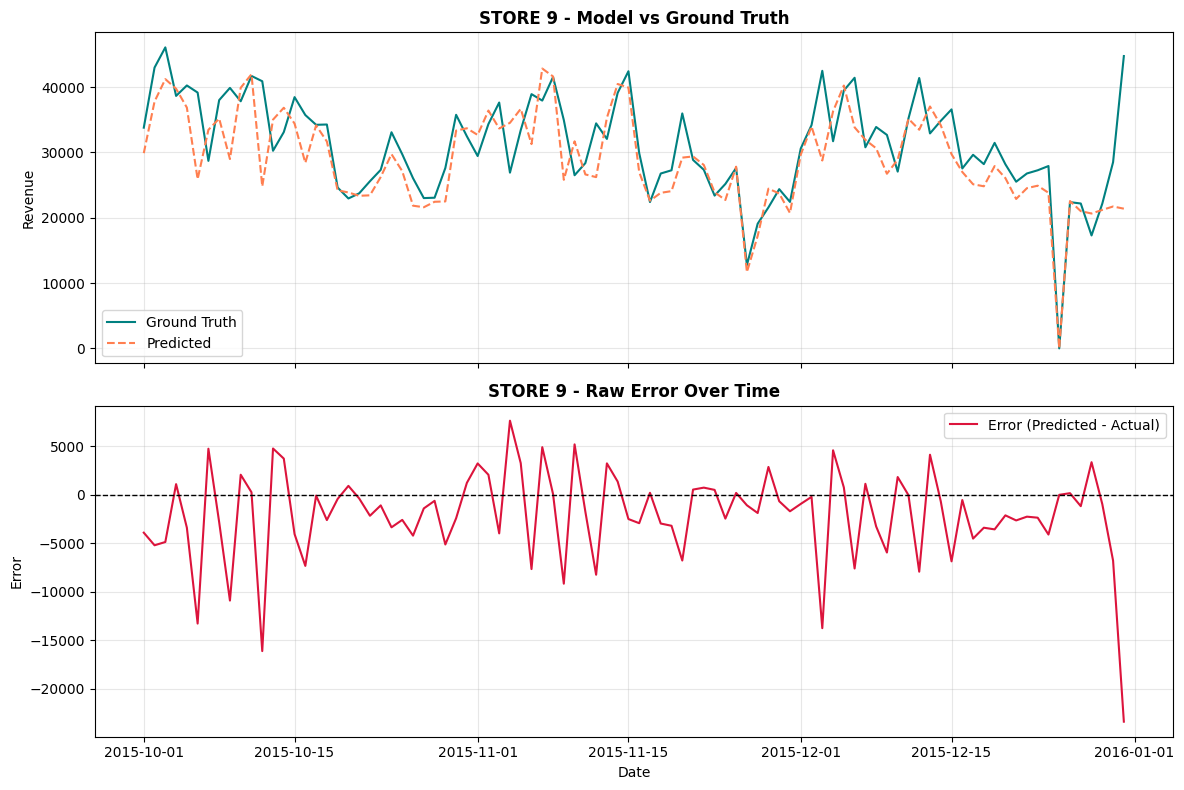


▶ STORE 10 METRICS:
  RMSE: 3,366.27  |  MAE: 2,462.87  |  MAPE: 10.92%


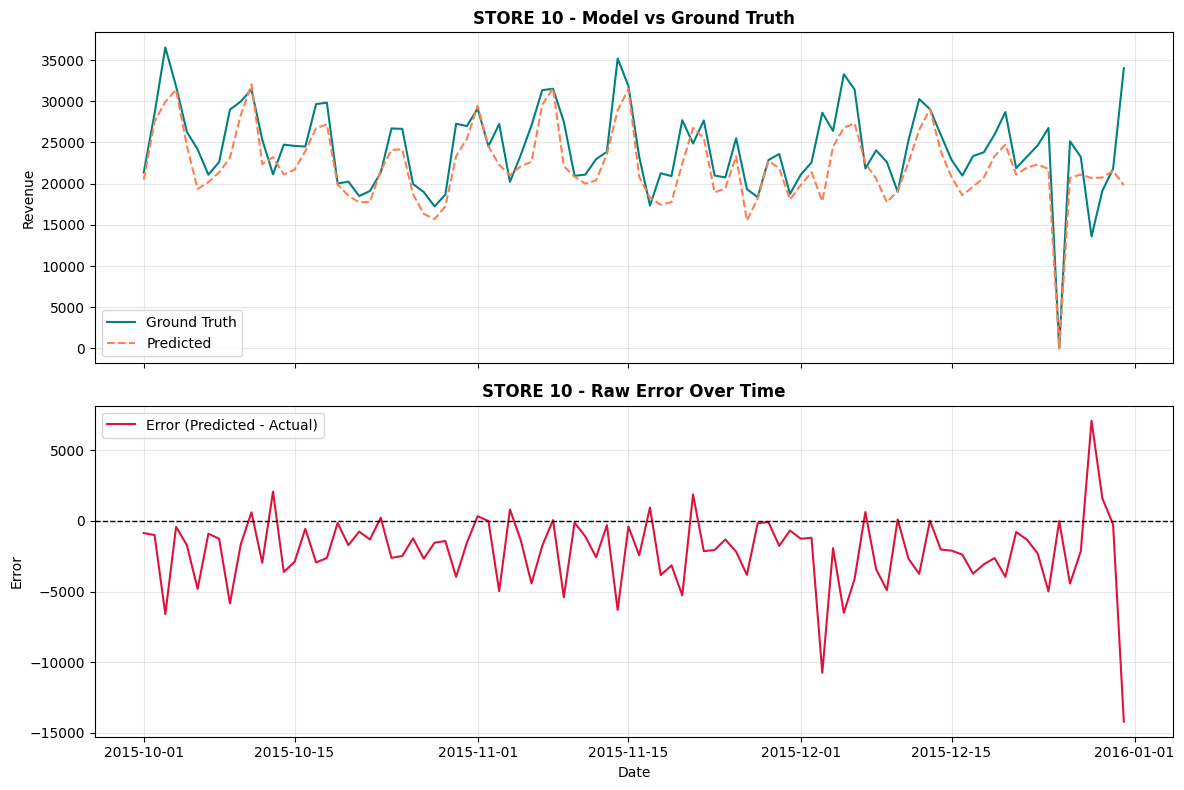

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the files
# Adjust the filename if yours is spelled slightly differently (e.g., format vs formated)
actual = pd.read_csv(r'ActualResult\actual_submission_formated_modified.csv')
results = pd.read_csv(r'Perdiction\results.csv')

# 2. Rename columns to avoid confusion
actual = actual.rename(columns={'prediction': 'actual'})
results = results.rename(columns={'prediction': 'predicted'})

# 3. Merge row-by-row on the 'id' column
df = pd.merge(actual, results, on='id')

# 4. Extract the store_id and date from the 'id' format (storeid_YYYYMMDD)
df[['store_id', 'date_str']] = df['id'].str.split('_', expand=True)
df['store_id'] = df['store_id'].astype(int)
df['date'] = pd.to_datetime(df['date_str'], format='%Y%m%d')

# 5. Calculate the raw error (Predicted - Actual)
# Positive means your model OVER-predicted. Negative means it UNDER-predicted.
df['error'] = df['predicted'] - df['actual']

# Calculate absolute error and percentage error for advanced metrics
df['abs_error'] = df['error'].abs()
# Prevent division by zero if actual revenue is exactly 0
df['pct_error'] = np.where(df['actual'] != 0, (df['abs_error'] / df['actual']) * 100, 0)

# Sort to ensure lines draw correctly over time
df = df.sort_values(['store_id', 'date'])

# ==========================================
# TEXT OUTPUT: GLOBAL METRICS
# ==========================================
overall_rmse = np.sqrt((df['error']**2).mean())
overall_mae = df['abs_error'].mean()
overall_mape = df['pct_error'].mean()
overall_bias = df['error'].mean() # Determines if model systematically over/under predicts
match_accuracy_5 = (df['pct_error'] <= 5).mean() * 100
match_accuracy_10 = (df['pct_error'] <= 10).mean() * 100

print("==================================================")
print(" 📊 GLOBAL FORECASTING PERFORMANCE (ALL DATA) ")
print("==================================================")
print(f"RMSE (Root Mean Squared Error):  {overall_rmse:,.2f}")
print(f"MAE (Mean Absolute Error):       {overall_mae:,.2f}")
print(f"Mean Bias (Overall Direction):   {overall_bias:,.2f} " + ("(Over-predicting)" if overall_bias > 0 else "(Under-predicting)"))
print(f"MAPE (Mean Abs Percentage):      {overall_mape:.2f}%")
print(f"Match Accuracy (Within ±5%):     {match_accuracy_5:.2f}% of predictions")
print(f"Match Accuracy (Within ±10%):    {match_accuracy_10:.2f}% of predictions")
print("==================================================\n")


# ==========================================
# PART 1: AGGREGATE PLOTS (Store 0)
# ==========================================
store0 = df[df['store_id'] == 0]

plt.figure(figsize=(14, 10))

# Top Subplot: The 2 Lines (Actual vs Predicted)
plt.subplot(2, 1, 1)
plt.plot(store0['date'], store0['actual'], label='Ground Truth (Actual)', color='teal', linewidth=2)
plt.plot(store0['date'], store0['predicted'], label='Model Prediction', color='coral', linewidth=2, linestyle='--')
plt.title('AGGREGATE (All Stores) - Model vs Ground Truth', fontsize=14, fontweight='bold')
plt.ylabel('Daily Revenue')
plt.legend()
plt.grid(alpha=0.3)

# Bottom Subplot: The Raw Error
plt.subplot(2, 1, 2)
plt.plot(store0['date'], store0['error'], label='Error (Predicted - Actual)', color='crimson', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5) # Zero line for reference
plt.title('AGGREGATE - Raw Error Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Error')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# PART 2: INDIVIDUAL STORE PLOTS (Stores 1-10)
# ==========================================
individual_stores = sorted([s for s in df['store_id'].unique() if s != 0])

print("\n==================================================")
print(" 🏪 INDIVIDUAL STORE BREAKDOWN ")
print("==================================================")

for store in individual_stores:
    store_df = df[df['store_id'] == store]

    # Calculate store-level metrics
    store_rmse = np.sqrt((store_df['error']**2).mean())
    store_mae = store_df['abs_error'].mean()
    store_mape = store_df['pct_error'].mean()

    print(f"\n▶ STORE {store} METRICS:")
    print(f"  RMSE: {store_rmse:,.2f}  |  MAE: {store_mae:,.2f}  |  MAPE: {store_mape:.2f}%")

    # Create a new figure for each store with 2 stacked charts
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Top Subplot: The 2 Lines
    ax1.plot(store_df['date'], store_df['actual'], label='Ground Truth', color='teal')
    ax1.plot(store_df['date'], store_df['predicted'], label='Predicted', color='coral', linestyle='--')
    ax1.set_title(f'STORE {store} - Model vs Ground Truth', fontweight='bold')
    ax1.set_ylabel('Revenue')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Bottom Subplot: The Raw Error
    ax2.plot(store_df['date'], store_df['error'], label='Error (Predicted - Actual)', color='crimson')
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.set_title(f'STORE {store} - Raw Error Over Time', fontweight='bold')
    ax2.set_ylabel('Error')
    ax2.set_xlabel('Date')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()